# Thư viện

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import normaltest, chi2_contingency
from sklearn.preprocessing import StandardScaler
import missingno as msno

In [2]:
utils_path = os.path.abspath(os.path.join(os.getcwd(), "../..", "src"))

if utils_path not in sys.path:
    sys.path.append(utils_path)

from utils import *
from little_mcar import *

In [3]:
CSV_PATH = "../../data/Tabular/raw/adult.csv"

In [4]:
df = pd.read_csv(CSV_PATH)
n = len(df)

# Phân tích thống kê tập dữ liệu

## Các thông tin cơ bản

In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Nhận thấy dữ liệu tồn tại các kí hiệu "?" tượng trưng cho thiếu dữ liêu, thực hiện thay thế bằng giá trị NaN để dễ xử lý.

In [6]:
df.replace("?", pd.NA, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


Dựa vào tóm tắt, dữ liệu gồm 32561 mẫu, gồm các biến số và chuỗi, trong đó có ba biến: "workclass", "occupation", "native.country" thiếu dữ liệu.

In [8]:
labels = df.columns.to_list()

num_cols = df.select_dtypes(include="number").columns.to_list()
cat_cols = df.select_dtypes(include=["object", "category", "str"]).columns.to_list()

print(f"Các biến số: {num_cols}")
print(f"Các biến chuỗi: {cat_cols}")

Các biến số: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Các biến chuỗi: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


## Kiểm tra phân phối (bằng kiểm định D'Agostino Pearson)

### Mục tiêu
Với mọi tập dữ liệu thu thập được, luôn tồn tại nhiễu gây ảnh hưởng đến kết quả của mô hình dự đoán.

Trong thực tế, ta không có dữ liệu của toàn bộ quần thể mà chỉ có thể lấy mẫu. Chính việc lấy mẫu luôn tồn tại sai lệch và nhiễu ngẫu nhiên.

Kiểm định giúp đảm bảo các giả định về mô hình thống kê được sử dụng là hợp lệ, tránh việc đánh giá dữ liệu sai lầm thông qua trực giác bản thân và trả lời câu hỏi dữ liệu ta có được có hiếm không nếu giả thuyết ban đầu của ta là đúng.

### Kiểm định D'Agostino-Pearson
Kiểm định D’Agostino–Pearson được sử dụng để kiểm tra dữ liệu có tuân theo phân phối chuẩn hay không với sự kết hợp thông tin về hình dạng phân phối.

* Skewness (độ lệch): dữ liệu có bị lệch trái/phải không.
* Kurtosis (độ nhọn): đuôi phân phối dày hay mỏng.

D'Agostino-Pearson không chỉ phát hiện dữ liệu lệch trái/phải mà còn phát hiện phân phối quá nhọn/bẹt giúp phát hiện sai lệch tốt hơn.

$$K^2 = Z_1^2 + Z_2^2$$
Trong đó:

* Z_1: skewness đã chuẩn hoá.
* Z_2: kurtosis đã chuẩn hoá.

Nếu dữ liệu thực sự chuẩn, giá trị kiểm định $K^2$ sẽ tuân theo phân phối chi-bình phương với 2 bậc tự do.

Với mức ý nghĩa alpha = 0.05

* Giả thuyết H0: Dữ liệu được lấy mẫu từ phân phối chuẩn

* Giả thuyết H1: Dữ liệu không được lấy mẫu từ phân phối chuẩn

* p <= alpha: Bác bỏ giả thuyết H0, dữ liệu không được lấy mẫu từ phân phối chuẩn

* p > alpha: Chấp nhận giả thuyết H0, dữ liệu có thể chuẩn.

In [9]:
results = {}

for col in num_cols:
    data = df[col].dropna()

    if len(data) >= 8:
        stat, p = normaltest(data)
        results[col] = p
    else:
        results[col] = np.nan

normal_cols = []
non_normal_cols = []

for col, p in results.items():
    if pd.isna(p):
        continue
    elif p > 0.05:
        normal_cols.append(col)
    else:
        non_normal_cols.append(col)

print("Normal: ", normal_cols)
print("Non-normal: ", non_normal_cols)

Normal:  []
Non-normal:  ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


Do số lượng mẫu lớn (hơn 30000), kiểm định D'Agostino Pearson rất nhạy, chỉ sai lệch nhỏ cũng sẽ làm p ~= 0, do đó cần sử dụng thêm các tiêu chí khác.

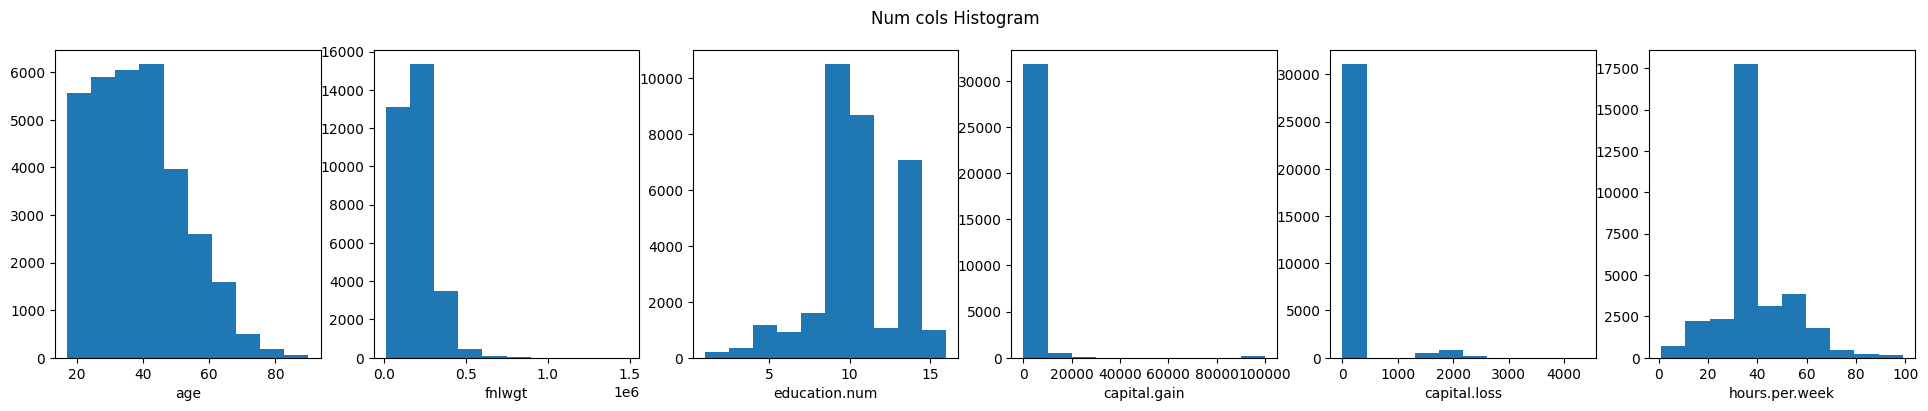

In [10]:
fig, ax = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
fig.suptitle("Num cols Histogram")

for i, col in enumerate(num_cols):
    ax[i].hist(df[col])
    ax[i].set_xlabel(col)

In [11]:
for col in num_cols:
    skew_score = df[col].skew()
    if abs(skew_score) < 0.5:
        print(f"{col} gần chuẩn")
    else:
        print(f"{col} lệch mạnh")

age lệch mạnh
fnlwgt lệch mạnh
education.num gần chuẩn
capital.gain lệch mạnh
capital.loss lệch mạnh
hours.per.week gần chuẩn


## Phân tích tương quan đa biến

### Mục tiêu

Phân tích tương quan giúp tìm ra mối quan hệ giữa các biến trong dữ liệu:
>Khi một biến thay đổi, biến kia có xu hướng thay đổi theo không, nếu có thì thay đổi theo hướng nào?

Khi trả lời được câu hỏi này, ta có thể:

* Hiểu cấu trúc dữ liệu: các biến nào đi cùng nhau, nhóm biến nào có xu hướng thay đổi với nhau, có nhân tố ẩn nào dẫn đến xu hướng này không, qua đó thực hiện các kiểm định khác như phân tích thành phần chính (PCA), phân tích nhân tố (Factor Analysis).
* Giải thích ý nghĩa các tham số của mô hình hồi quy.
* Loại bỏ biến dư thừa, do chỉ một biến cũng có thể biểu diễn được pattern của dữ liệu, giúp giảm chiều dữ liệu, giữ lại biến có tương quan mạnh với target, làm tăng đáng kể hiệu quả và khả năng giải thích của mô hình.

Đại lượng thường dùng là hệ số tương quan (correlation coefficient), trong đó:

* Tương quan Pearson: thể hiện quan hệ tuyến tính, xu hướng thay đổi của hai biến có nằm trên một đường thẳng không.
* Tương quan Spearman: thể hiện quan hệ đơn điệu, khi một biến tăng thì biến còn lại có luôn tăng/giảm không.



In [12]:
pearson_corr = df[num_cols].corr(method="pearson")
spearman_corr = df[num_cols].corr(method="spearman")

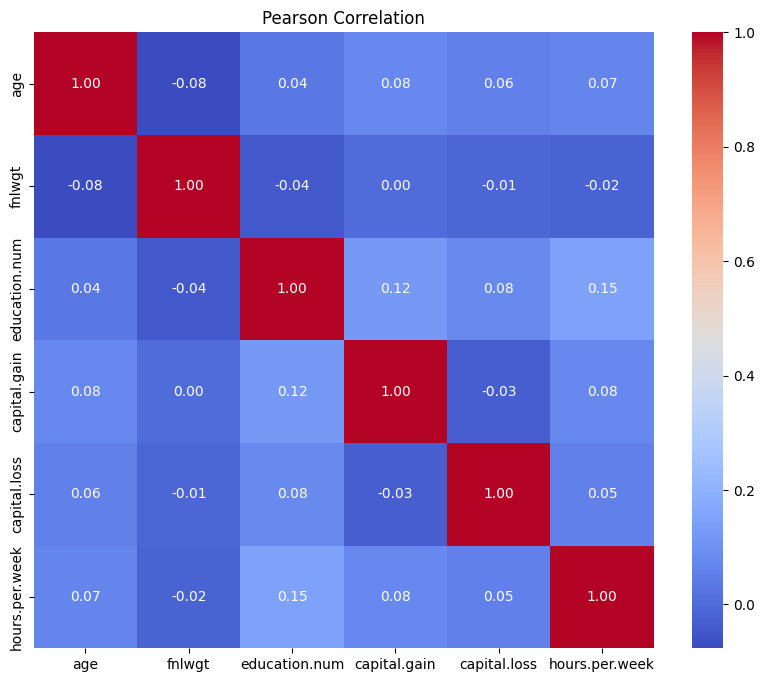

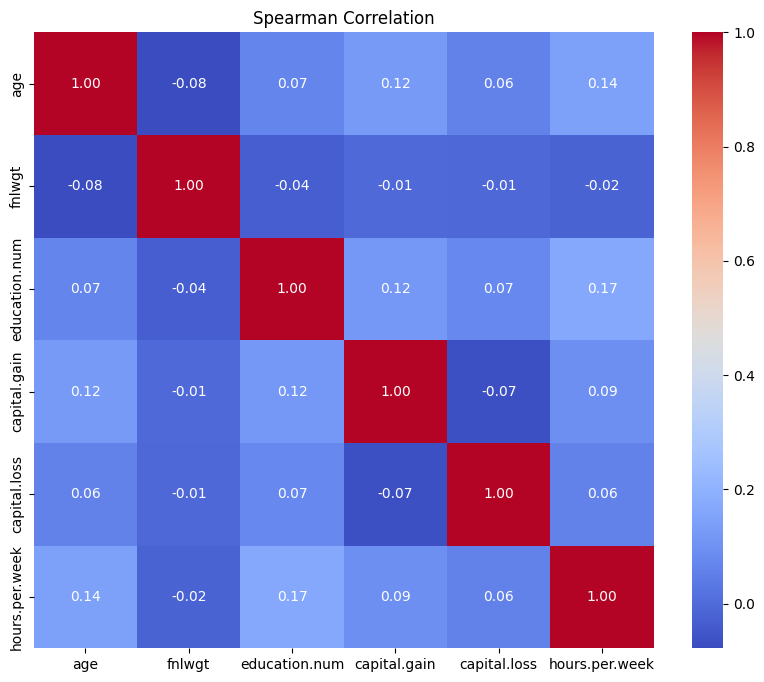

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Correlation")
plt.show()

In [14]:
def find_high_corr(corr_matrix, threshold=0.9):
    pairs = []
    cols = corr_matrix.columns
    
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > threshold:
                pairs.append((cols[i], cols[j], r))
    
    return pairs

pearson_pairs = find_high_corr(pearson_corr)
spearman_pairs = find_high_corr(spearman_corr)

print("High Pearson:", pearson_pairs)
print("High Spearman:", spearman_pairs)

High Pearson: []
High Spearman: []


Không phát hiện cặp biến nào có |r| > 0.9 khi sử dụng Pearson và Spearman, do đó không tồn tại đa cộng tuyến mạnh.

-> Không cần loại bỏ biến dựa trên tương quan.

## Phân tích dữ liệu thiếu

### Mục tiêu

Dữ liệu thiếu sẽ dẫn đến kết luận sai lệch, nếu không phân tích, trung bình, phân phối có thể bị lệch.

Nhiều thuật toán không thể xử lý được với dữ liệu thiếu hoặc xử lý sai làm giảm độ chính xác và không nắm bắt được pattern của dữ liệu.

Ngoài ra, thiếu dữ liệu có thể tạo tương quan giả, làm sai kết quả phân tích tương quan và kiểm định giả thuyết.

### Cơ chế thiếu dữ liệu:

* MCAR (Missing Completely At Random): Thiếu dữ liệu hoàn toàn ngẫu nhiên, không phụ thuộc vào bất kỳ biến nào (quan sát hay không quan sát). Có thể xác định bằng kiểm định Little MCAR.
* MAR (Missing At Random): Thiếu dữ liệu phụ thuộc vào các biến quan sát được khác, nhưng không phụ thuộc vào chính giá trị bị thiếu. Có thể suy luận gián tiếp bằng cách kiểm tra tương quan giữa biến thiếu và các biến khác.
* MNAR (Missing Not At Random): Thiếu dữ liệu phụ thuộc vào ý nghĩa của biến thiếu dữ liệu. Không thể kiểm định trực tiếp từ dữ liệu, cần kiến thức miền (domain knowledge) hoặc giả định mô hình để kiểm tra.

<Axes: >

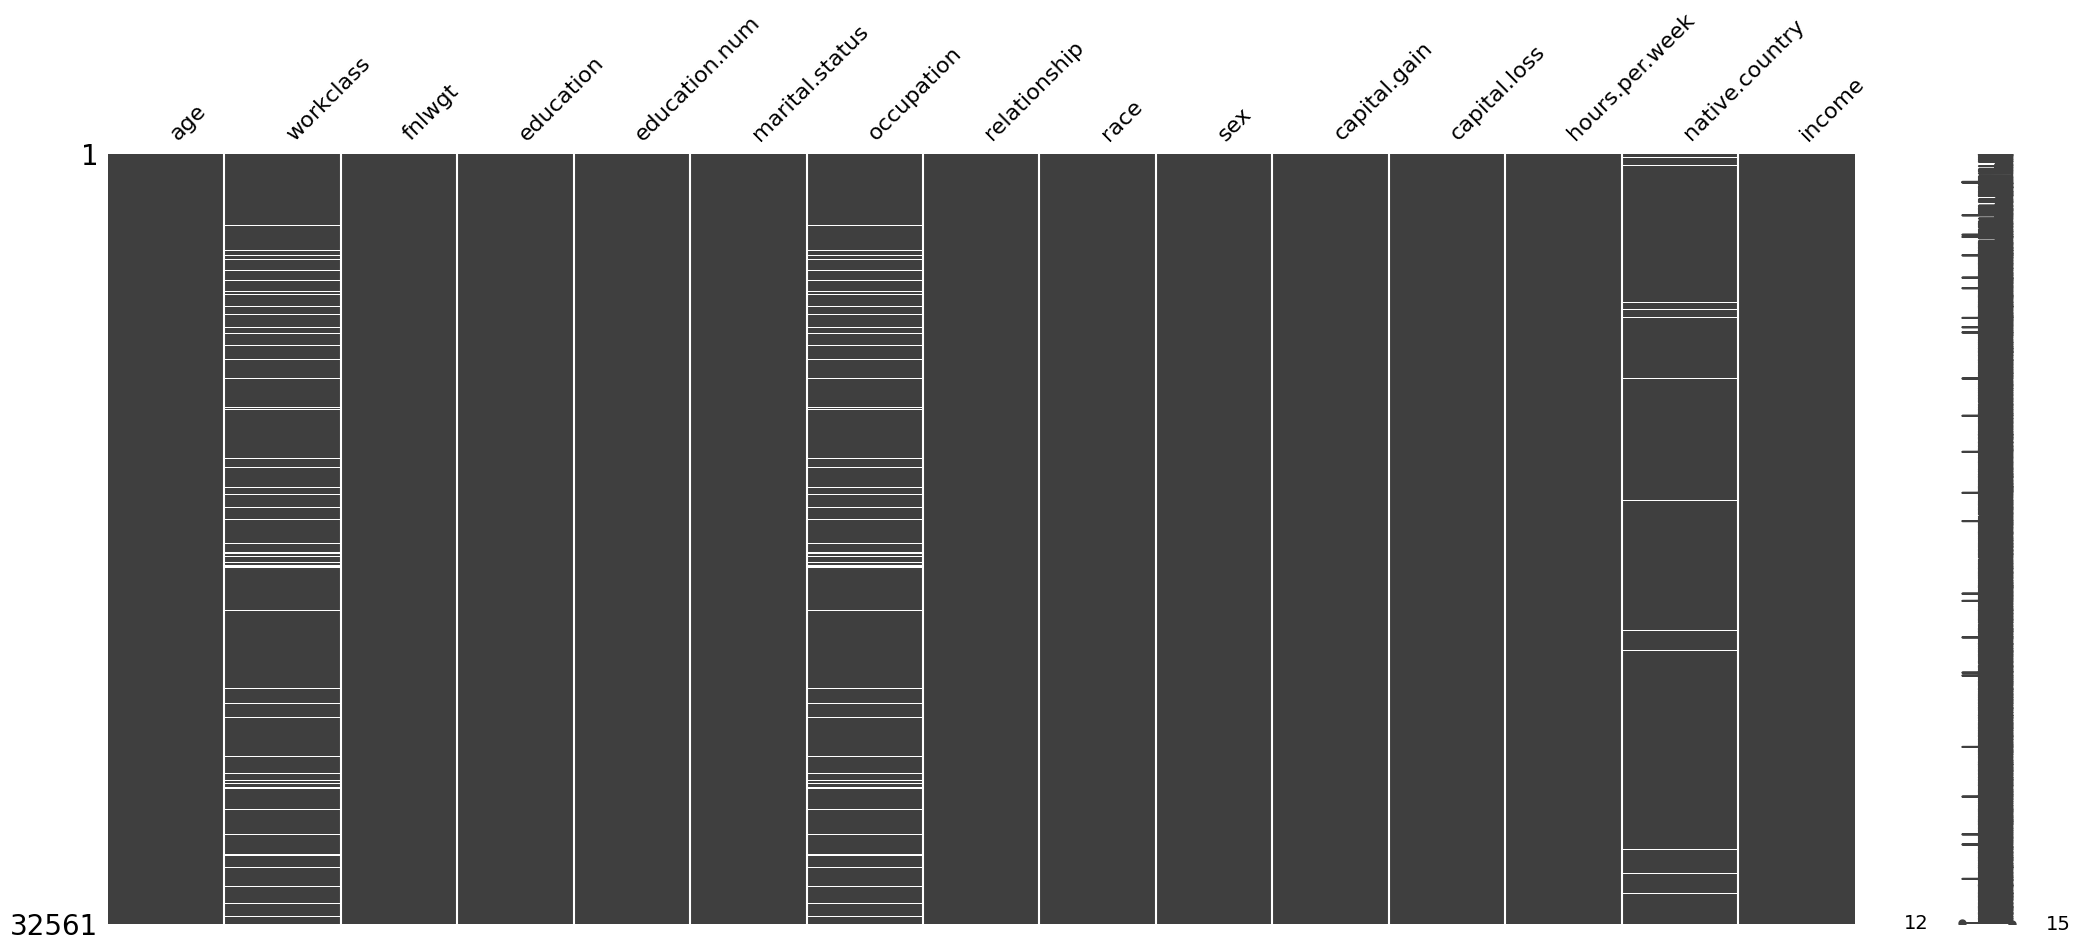

In [15]:
msno.matrix(df)

Dựa vào ma trận thiếu dữ liệu, các biến "workclass", "occupation", "native_country" là các biến duy nhất thiếu dữ liệu.

In [16]:
print("Số lượng mẫu thiếu thuộc tính")
null_counts = df.isna().sum()
print(null_counts[null_counts > 0])

print()

print("Tỉ lệ mẫu thiếu thuộc tính")
print((null_counts / df.count())[null_counts > 0] * 100)

print()

print("Số mẫu thiếu dữ liệu")
count = df.isnull().any(axis=1).sum()
print(count)

print()

print("Tỉ lệ mẫu thiếu dữ liệu")
print(count / n * 100)

Số lượng mẫu thiếu thuộc tính
workclass         1836
occupation        1843
native.country     583
dtype: int64

Tỉ lệ mẫu thiếu thuộc tính
workclass         5.975590
occupation        5.999740
native.country    1.823128
dtype: float64

Số mẫu thiếu dữ liệu
2399

Tỉ lệ mẫu thiếu dữ liệu
7.367709836921471


### Kiểm định Little's MCAR

Kiểm định Little's MCAR kiểm tra dữ liệu thiếu có hoàn toàn ngẫu nhiên hay không (hay tồn tại một pattern nào đó).

Nếu dữ liệu là MCAR, các mẫu có missing và không missing phải giống nhau về mặt thống kê. Little's MCAR kiểm tra điều này bằng cách:

1. Chia dữ liệu thành các nhóm theo pattern missing.
2. So sánh trung bình của các biến giữa các nhóm.

Nếu các nhóm khác biệt đáng kể thì dữ liệu không phải MCAR.

Với mức ý nghĩa alpha = 0.05:

* Giả thuyết H0: Dữ liệu thiếu theo MCAR.
* Giả thuyết H1: Dữ liệu không thiếu theo MCAR.
* p_value <= alpha: Bác bỏ giả thuyết H0, dữ liệu không thiếu theo MCAR.
* p_value > alpha: Chấp nhận giả thuyết H0, nghĩa là dữ liệu có thể thiếu theo MCAR.


Do tập dữ liệu Adult Census thiếu dữ liệu ở các biến phân loại: "workclass", "occupation", "native.country", không thể sử dụng Little's MCAR test để kiểm định giả thuyết các biến có phải là MCAR hay không. Do Little's MCAR test kiểm tra trên dữ liệu số liên tục, việc mã hoá các biến phân loại về số làm mất ý nghĩa của trung bình và phương sai được sử dụng trong Little's MCAR test.

Vì vậy, nhóm sẽ thực hiện xoá giá trị ngẫu nhiên trên tập dữ liệu số với tỉ lệ 10% và thực hiện Little's MCAR test trên dữ liệu này.

In [17]:
def mcar(df: pd.DataFrame, missing_rate=0.1) -> tuple[pd.DataFrame, np.ndarray]:
    df_missing = df.copy()
    mask = np.random.rand(*df.shape) < missing_rate

    df_missing[mask] = np.nan

    return df_missing, mask

In [18]:
df_num = df[num_cols].copy()
standard_std = StandardScaler().set_output(transform="pandas")
df_num = standard_std.fit_transform(df_num)
df_missing, mask = mcar(df_num, 0.1)

In [24]:
mcar_summary(df_missing)

result = little_mcar_test(df_missing)
print()
# print(result)
print(f"p-value = {result.p_value}  |  stat = {result.statistic}")

  Little's MCAR Test
  Numeric columns   : ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
  Rows              : 32561
  Missing cells     : 19616 / 195366 (10.0%)
  Missing patterns  : 57
------------------------------------------------------------
  Chi-square stat   : 147.5800
  Degrees of freedom: 179
  p-value           : 0.9585
------------------------------------------------------------
  Verdict: Chấp nhận H0 (p=0.9585 ≥ 0.05): dữ liệu có thể là MCAR.

p-value = 0.9585  |  stat = 147.58


Thực hiện kiểm tra MAR giữa 3 biến "workclass", "occupation", "native.country" bằng Chi-square test of independence:

Với mức ý nghĩa alpha = 0.05:

* Giả thuyết H0: Hai biến độc lập với nhau.
* Giả thuyết H1: Hai biến phụ thuộc nhau.
* p_value <= alpha: Bác bỏ giả thuyết H0, nghĩa là hai biến có thể phụ thuộc nhau.
* p_value > alpha: Chấp nhận giả thuyết H0, nghĩa là hai biến độc lập với nhau.

In [20]:
df["workclass_missing"] = df["workclass"].isna().astype(int)
df["occupation_missing"] = df["occupation"].isna().astype(int)
df["native_country_missing"] = df["native.country"].isna().astype(int)

In [21]:
table = pd.crosstab(df["workclass_missing"], df["occupation"])
chi2, p, _, _ = chi2_contingency(table)

print(f"p-value: {p}")

table = pd.crosstab(df["workclass_missing"], df["native.country"])
chi2, p, _, _ = chi2_contingency(table)
print(f"p-value: {p}")

p-value: 1.0
p-value: 0.1112386761171071


p_value = 1 > 0.05, chấp nhận giả thuyết H0, nghĩa là workclass không phụ thuộc vào occupation.

p_value = 0.11 > 0.05, chấp nhận giả thuyết H0, nghĩa là workclass không phụ thuộc vào native.country.

In [22]:
table = pd.crosstab(df["occupation_missing"], df["workclass"])
chi2, p, _, _ = chi2_contingency(table)

print(f"p-value: {p}")

table = pd.crosstab(df["occupation_missing"], df["native.country"])
chi2, p, _, _ = chi2_contingency(table)
print(f"p-value: {p}")

p-value: 0.0
p-value: 0.11310984929650865


p_value = 0 < 0.05, bác bỏ giả thuyết H0, chấp nhận H1, nghĩa là occupation phụ thuộc vào workclass.

p_value = 0.11 > 0.05, chấp nhận giả thuyết H0, nghĩa là occupation không phụ thuộc vào native.country.

In [23]:
table = pd.crosstab(df["native_country_missing"], df["workclass"])
chi2, p, _, _ = chi2_contingency(table)

print(f"p-value: {p}")

table = pd.crosstab(df["native_country_missing"], df["occupation"])
chi2, p, _, _ = chi2_contingency(table)
print(f"p-value: {p}")

p-value: 0.000122826812284251
p-value: 2.5549808598796595e-05


p_value = 0 < 0.05, bác bỏ giả thuyết H0, chấp nhận H1, nghĩa là native.country phụ thuộc vào workclass.

p_value = 0 < 0.05, bác bỏ giả thuyết H0, chấp nhận H1, nghĩa là native.country phụ thuộc vào occupation.